In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [ ]:
sp.constants

In [ ]:
class PEMMHoopSolver:
  def __init__(self, N, phi_m, phi_M, r):
    self.N = N
    self.phi_M = phi_M
    self.phi_m = phi_m
    self.r = r

  def calculatePiecewiseConstantCoefficients(self, V):
    Z = np.empty((self.N, self.N))
    delta = (self.phi_M - self.phi_m)/self.N
    for m in range(self.N):
      for n in range(self.N):
        dUpper = 0.5 * (n-m+0.5) * delta
        dLower = 0.5 * (n-m-0.5) * delta
        Z[m][n] = abs(-np.log(abs((1+np.cos(dUpper))/np.sin(dUpper) / ((1+np.cos(dLower))/np.sin(dLower)))))
    self.c = 4*np.pi*sp.constants.epsilon_0*self.r*np.dot(np.linalg.inv(Z), V)
    return self.c

  def plotChargeDistribution(self):
    cIndices = np.linspace(0, self.N, self.N)
    x = ((self.phi_M - self.phi_m)/self.N*cIndices + self.phi_m)/np.pi
    plt.plot(x, self.c)

In [ ]:
r = 1

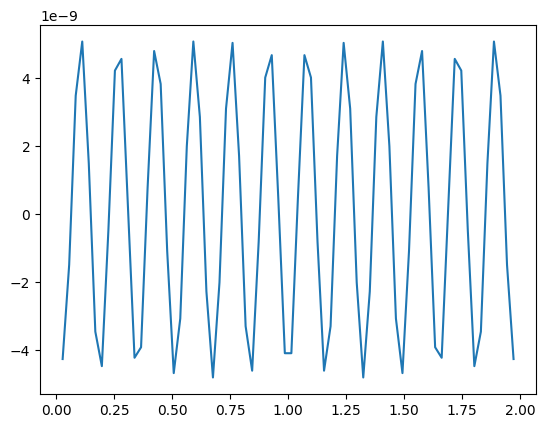

In [ ]:
N = 70

V = np.ones(N)*10*r**2
solver = PEMMHoopSolver(N, 5*np.pi/180, 355*np.pi/180, r)
c = solver.calculatePiecewiseConstantCoefficients(V)
solver.plotChargeDistribution()